# 02 · Regime Detection
Train the Gaussian HMM, decode regimes, and explore the results interactively.

In [12]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import matplotlib.pyplot as plt

from src.data_loader import download_price_data, load_close_series
from src.feature_engineering import build_feature_matrix
from src.hmm_model import (
    build_hmm, fit_hmm, predict_states,
    compute_state_statistics, label_states,
    build_regime_dataframe, print_model_diagnostics,
    save_model,
)
from src.visualization import (
    plot_closing_price, plot_price_by_regime,
    plot_return_histograms, plot_transition_matrix,
)
from src.utils import configure_logging, resolve_path, print_state_statistics

configure_logging()
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [8]:
TICKER = 'INFY.NS'
START  = '2010-01-01'
END    = '2026-06-01'

raw   = download_price_data(TICKER, START, END, resolve_path('data', 'raw'))
close = load_close_series(raw)
log_returns, X, scaler = build_feature_matrix(close)
print(f'Feature matrix: {X.shape}')

18:28:21  INFO      src.data_loader — Downloading INFY.NS from 2010-01-01 to 2026-06-01
18:28:23  INFO      src.data_loader — Saved raw data to /Users/shyambanerjee/Program Files/algo_trad/algo_trad_codes/projects/regime_detector/data/raw/INFY.NS_2010-01-01_2026-06-01.csv
18:28:23  INFO      src.feature_engineering — Computed 4049 log-return observations (0.0004 mean, 0.017202 std)
18:28:23  INFO      src.feature_engineering — Features standardised — mean≈-0.0000, std≈1.0000
Feature matrix: (4049, 1)


In [9]:
model = build_hmm()
model = fit_hmm(model, X)
states = predict_states(model, X)
print_model_diagnostics(model)

18:28:25  INFO      src.hmm_model — Fitting HMM with 3 components …
18:28:25  INFO      src.hmm_model — HMM fitted — log-likelihood: -5206.9449
18:28:25  INFO      src.hmm_model —   State 0 — 1934 observations (47.8%)
18:28:25  INFO      src.hmm_model —   State 1 — 1943 observations (48.0%)
18:28:25  INFO      src.hmm_model —   State 2 — 172 observations (4.2%)

HMM MODEL DIAGNOSTICS

▸ Initial state probabilities  (model.startprob_)
  The probability that the Markov chain starts in each hidden
  state on the very first observation.  A high value for one
  state implies the market is most commonly in that regime at
  the beginning of the time series.
    State 0: 0.0001
    State 1: 0.9999
    State 2: 0.0000

▸ State transition matrix  (model.transmat_)
  transmat_[i, j] is the probability of transitioning from
  state i to state j on the next time step.  Values close to
  1 on the diagonal indicate persistent (sticky) regimes.
         → S0  → S1  → S2
  S0 →  0.0053  0.9945  0.0002


In [10]:
stats     = compute_state_statistics(log_returns, states)
labels    = label_states(stats)
regime_df = build_regime_dataframe(log_returns, states, labels)
print_state_statistics(stats, labels)

18:28:28  INFO      src.hmm_model — Derived regime labels: {0: 'Low Volatility Bull', 2: 'Crash / Bear Regime', 1: 'High Volatility Bull'}

REGIME SUMMARY STATISTICS
                     Mean Return Volatility  Count Frequency
Regime                                                      
Low Volatility Bull     0.000499   0.012473  1,934    47.76%
High Volatility Bull    0.000890   0.013365  1,943    47.99%
Crash / Bear Regime    -0.006050   0.056328    172     4.25%



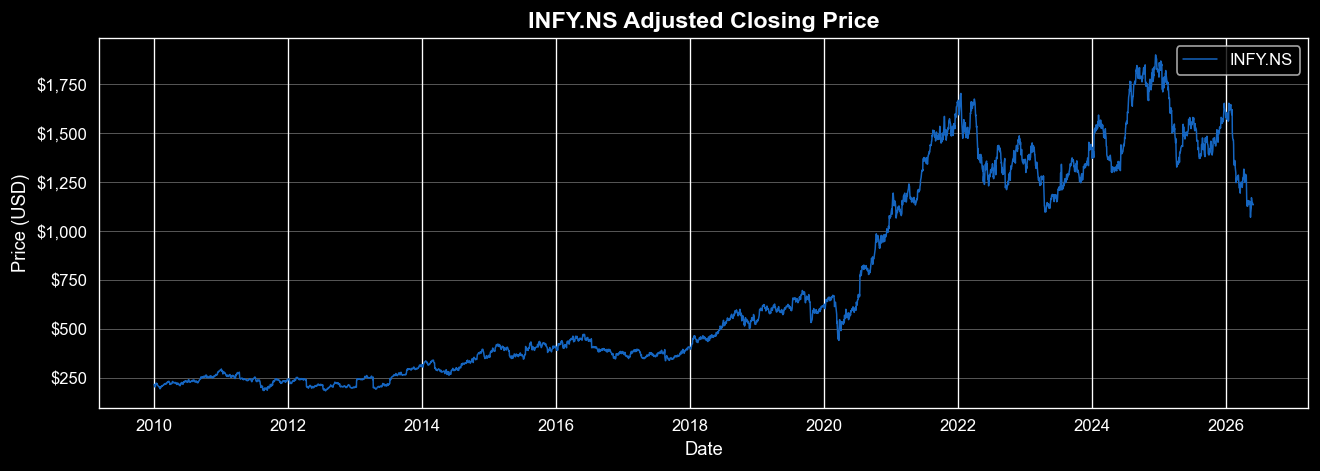

In [11]:
fig = plot_closing_price(close, TICKER)
plt.show()

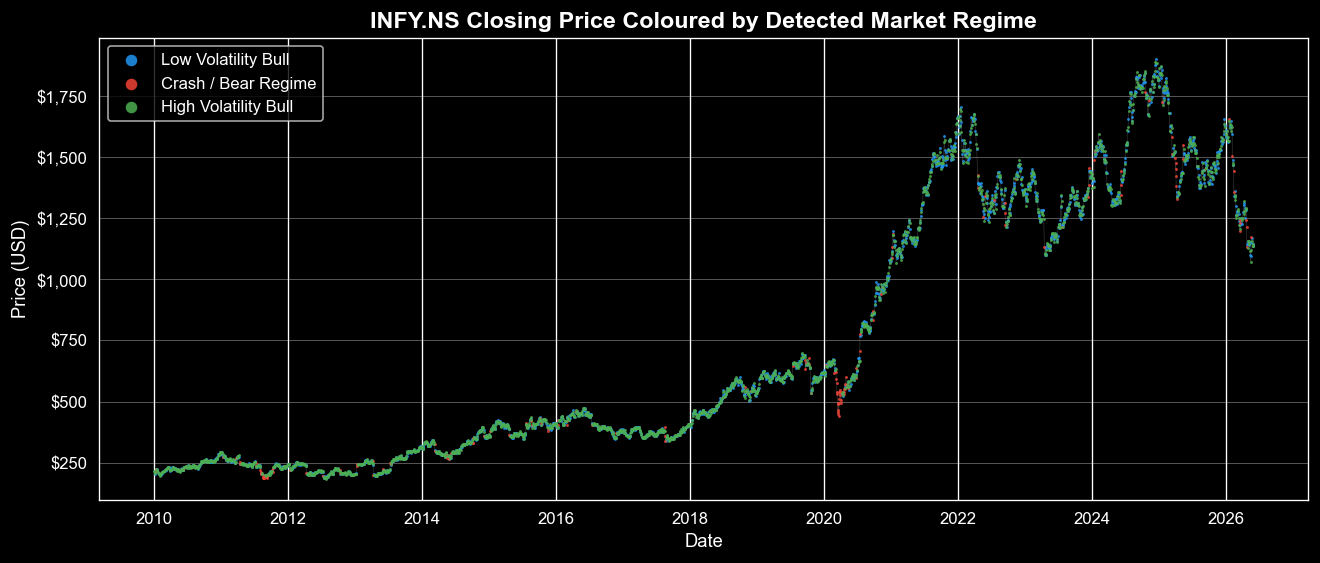

In [13]:
fig = plot_price_by_regime(close, regime_df, labels, TICKER)
plt.show()

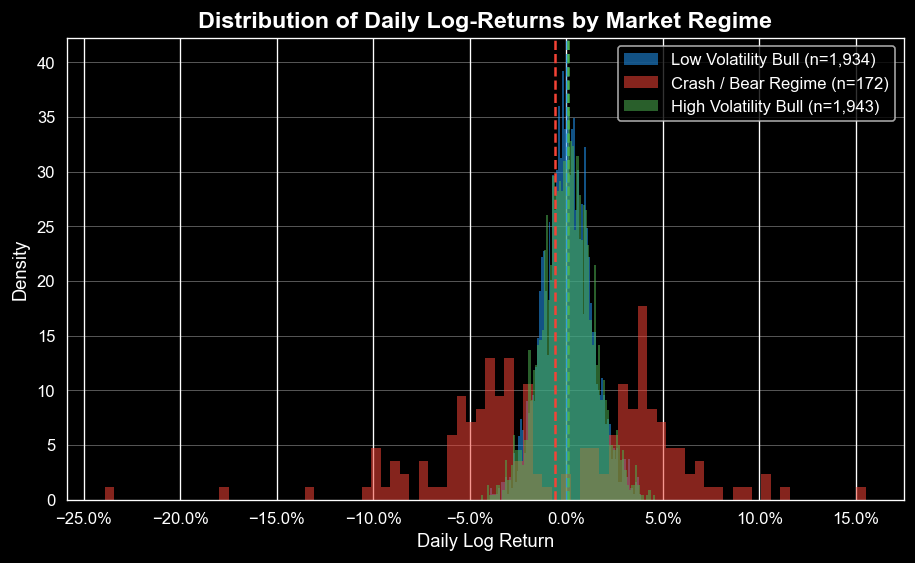

In [14]:
fig = plot_return_histograms(regime_df, labels)
plt.show()

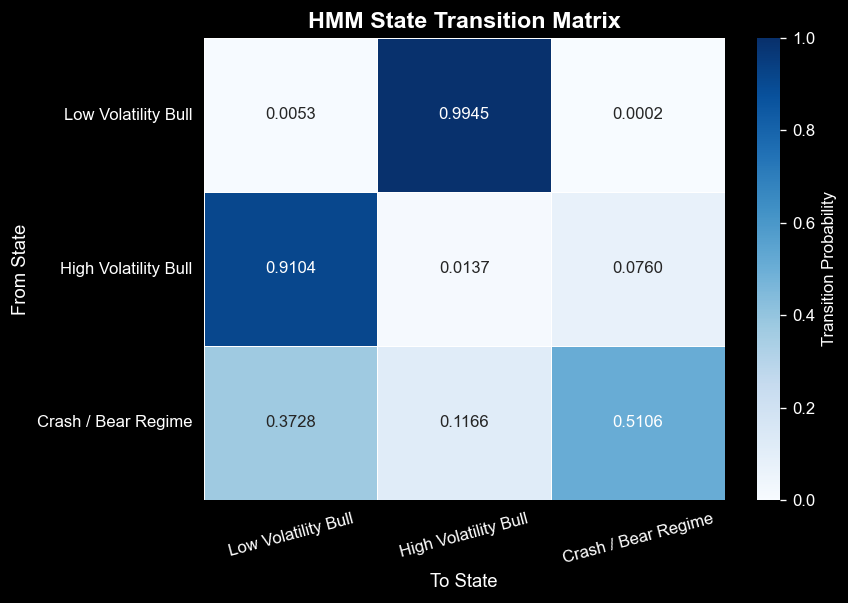

In [15]:
fig = plot_transition_matrix(model.transmat_, labels)
plt.show()

In [16]:
save_model(model, resolve_path('outputs', 'models', f'hmm_{TICKER.lower()}.pkl'))
regime_df.to_csv(resolve_path('outputs', f'regime_labels_{TICKER.lower()}.csv'))
print('Artefacts saved.')

18:29:28  INFO      src.hmm_model — Model saved to /Users/shyambanerjee/Program Files/algo_trad/algo_trad_codes/projects/regime_detector/outputs/models/hmm_infy.ns.pkl
Artefacts saved.
